In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(title, img, cmap='gray'):
    plt.figure(figsize=(4,4))
    plt.title(title)
    plt.imshow(img, cmap=cmap)
    plt.axis('off')


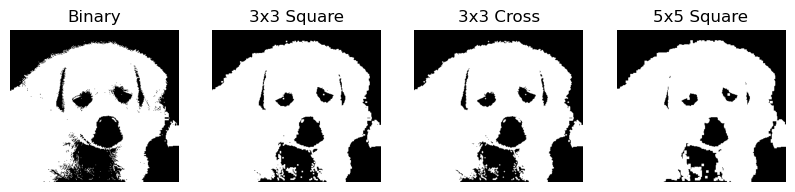

In [2]:
img = cv2.imread('image 2.jpg', cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

se_square_3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
se_cross_3  = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
se_square_5 = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))

d1 = cv2.dilate(binary, se_square_3)
d2 = cv2.dilate(binary, se_cross_3)
d3 = cv2.dilate(binary, se_square_5)

plt.figure(figsize=(10,4))
for i,(t,img_) in enumerate(zip(
    ["Binary","3x3 Square","3x3 Cross","5x5 Square"],
    [binary,d1,d2,d3]
)):
    plt.subplot(1,4,i+1)
    plt.title(t)
    plt.imshow(img_, cmap='gray')
    plt.axis('off')
plt.show()


Different SE shapes grow objects differently; cross grows along axes, square grows uniformly.

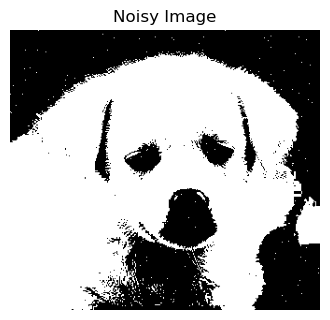

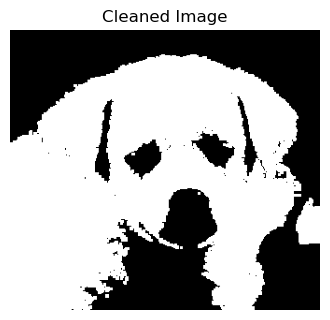

In [3]:
noisy = binary.copy()
coords = [np.random.randint(0, i-1, 300) for i in noisy.shape]
noisy[coords[0], coords[1]] = 255

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
cleaned = cv2.morphologyEx(noisy, cv2.MORPH_OPEN, kernel)

show("Noisy Image", noisy)
show("Cleaned Image", cleaned)


Opening is most effective for removing salt noise without damaging objects.

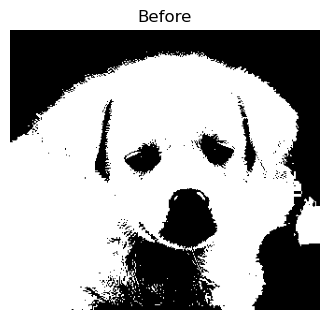

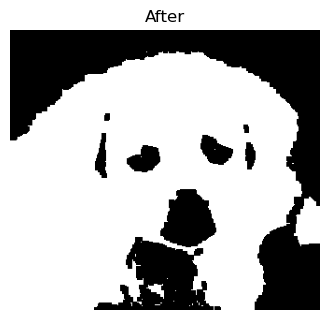

In [4]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
filled = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

show("Before", binary)
show("After", filled)


Too large SE over-smooths and enlarges objects unnaturally.

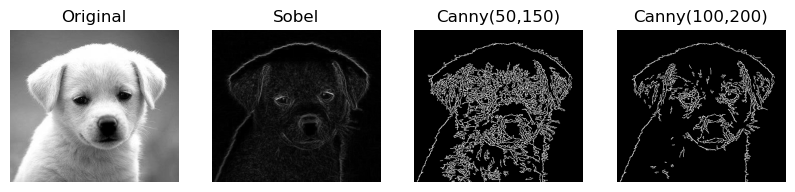

In [5]:
gray = img.copy()

sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
sobel = cv2.magnitude(sx, sy)

canny1 = cv2.Canny(gray, 50, 150)
canny2 = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10,4))
for i,(t,img_) in enumerate(zip(
    ["Original","Sobel","Canny(50,150)","Canny(100,200)"],
    [gray,sobel,canny1,canny2]
)):
    plt.subplot(1,4,i+1)
    plt.title(t)
    plt.imshow(img_, cmap='gray')
    plt.axis('off')
plt.show()


Weak edges disappear first as Canny thresholds increase.

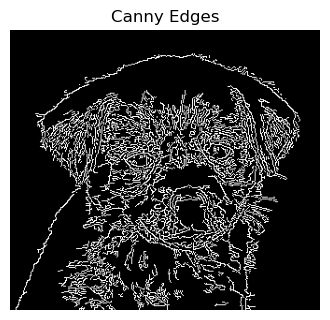

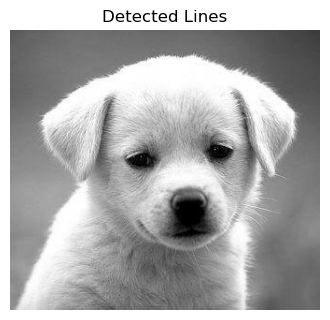

In [6]:
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

line_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for rho,theta in lines[:20]:
        a,b = np.cos(theta), np.sin(theta)
        x0,y0 = a*rho, b*rho
        x1,y1 = int(x0+1000*(-b)), int(y0+1000*(a))
        x2,y2 = int(x0-1000*(-b)), int(y0-1000*(a))
        cv2.line(line_img,(x1,y1),(x2,y2),(0,0,255),1)

show("Canny Edges", edges)
show("Detected Lines", line_img, cmap=None)


Too low Hough threshold detects many false lines (noise).

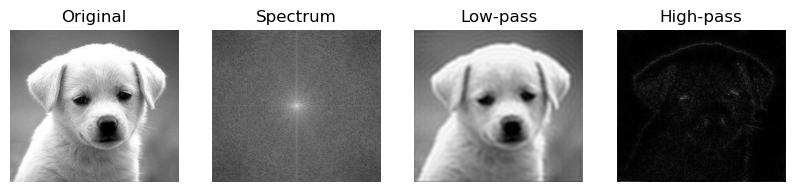

In [7]:
f = np.fft.fft2(gray)
fshift = np.fft.fftshift(f)
magnitude = np.log(np.abs(fshift)+1)

rows, cols = gray.shape
crow, ccol = rows//2, cols//2

mask_low = np.zeros((rows,cols),np.uint8)
cv2.circle(mask_low,(ccol,crow),30,1,-1)

mask_high = 1 - mask_low

low = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift*mask_low)))
high = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift*mask_high)))

plt.figure(figsize=(10,4))
for i,(t,img_) in enumerate(zip(
    ["Original","Spectrum","Low-pass","High-pass"],
    [gray,magnitude,low,high]
)):
    plt.subplot(1,4,i+1)
    plt.title(t)
    plt.imshow(img_, cmap='gray')
    plt.axis('off')
plt.show()


High-pass filtering enhances edges more strongly.

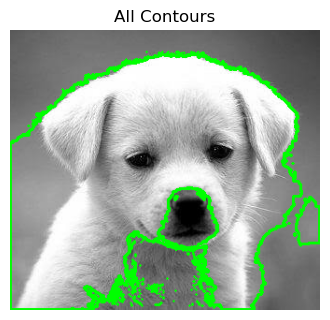

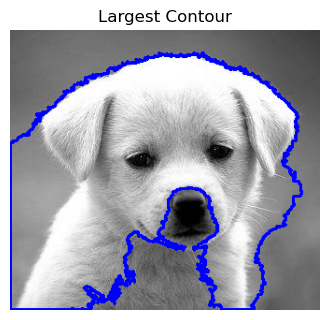

In [8]:
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

all_c = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(all_c, contours, -1, (0,255,0), 2)

largest = max(contours, key=cv2.contourArea)
largest_c = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(largest_c, [largest], -1, (0,0,255), 2)

show("All Contours", all_c, cmap=None)
show("Largest Contour", largest_c, cmap=None)


Poor thresholding creates broken or missing contours.

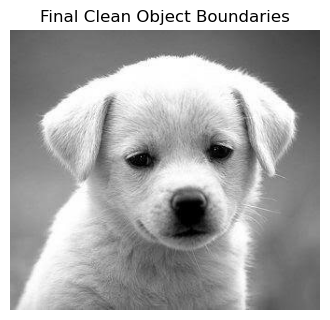

In [10]:
clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, se_square_3)
edges = cv2.Canny(clean, 50, 150)

contours,_ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

for c in contours:
    if cv2.contourArea(c) > 200:
        cv2.drawContours(final,[c],-1,(255,0,0),2)

show("Final Clean Object Boundaries", final, cmap=None)
